# Statistical Analysis of Cleaned Titanic Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
BLUE, ORANGE, GREEN, RED, PURPLE = '#2563EB','#F97316','#16A34A','#DC2626','#7C3AED'
Titanic_cleaned = pd.read_csv(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_3_Project\Week_3_Titanic_Project\Titanic_Cleaned.csv")
Titanic_cleaned.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Sex_enc,Embarked_enc,FamilySize,IsAlone
0,0,3,male,22.0,1,0,7.2500,S,0,0,2,0
1,1,1,female,38.0,1,0,71.2833,C,1,1,2,0
2,1,3,female,26.0,0,0,7.9250,S,1,0,1,1
3,1,1,female,35.0,1,0,53.1000,S,1,0,2,0
4,0,3,male,35.0,0,0,8.0500,S,0,0,1,1


In [2]:
# Descriptive statistic
num_cols = ['Age','Fare','SibSp','Parch']
desc_stats = []
for col in num_cols:
    mean_v = Titanic_cleaned[col].mean()
    median_v = Titanic_cleaned[col].median()
    mode_v = Titanic_cleaned[col].mode()[0]
    desc_stats.append({
        'Mean': mean_v,
        'Median': median_v,
        'Mode': mode_v
    })
pd.DataFrame(desc_stats, index=num_cols)

,Mean,Median,Mode
Age,29.361582,28.0000,28.00
Fare,32.204208,14.4542,8.05
SibSp,0.523008,0.0000,0.00
Parch,0.381594,0.0000,0.00


In [3]:
# Variance & Standard Deviation 
var_std_stats = []
for col in num_cols:
    var_v = Titanic_cleaned[col].var()
    std_v = Titanic_cleaned[col].std()
    var_std_stats.append({
        'Column': col,
        'Variance': var_v,
        'Std Dev': std_v
    })
pd.DataFrame(var_std_stats)

,Column,Variance,Std Dev
0,Age,169.512498,13.019697
1,Fare,2469.436846,49.693429
2,SibSp,1.216043,1.102743
3,Parch,0.649728,0.806057


In [4]:
# Skewness & Kurtosis 
Skew_Kurt_stats = []
for col in num_cols:
    skew_v = Titanic_cleaned[col].skew()
    kurt_v = Titanic_cleaned[col].kurt()
    Skew_Kurt_stats.append({
        'Column': col,
        'Skewness': skew_v,
        'Kurtosis': kurt_v
    })
pd.DataFrame(Skew_Kurt_stats)


,Column,Skewness,Kurtosis
0,Age,0.510245,0.993871
1,Fare,4.787317,33.398141
2,SibSp,3.695352,17.880420
3,Parch,2.749117,9.778125


# Interpretation of Skewness and Kurtois

1. Fare (skew=4.79) is EXTREMELY right-skewed meaning a hanTitanic_cleanedul of very high fares (up to £512) pull the distribution far to the right.

2. Age (skew=0.51) is mildly right-skewed meaning Age shows mild right skewness (0.51), suggesting that while most passengers are relatively young, a smaller number of older passengers increase the tail of the distribution toward higher ages.

In [5]:
# Survival rate (proportion statistic) 

overall_survival_rate = round(Titanic_cleaned['Survived'].mean() * 100, 1)

survival_rate_by_sex = (Titanic_cleaned.groupby('Sex')['Survived'].mean().mul(100).round(1))

survival_rate_by_pclass = (Titanic_cleaned.groupby('Pclass')['Survived'].mean().mul(100).round(1))

pd.DataFrame({'Survival Rate by Sex (%)': survival_rate_by_sex})
pd.DataFrame({'Survival Rate by Pclass (%)': survival_rate_by_pclass})
survival_summary = {
    'Overall Survival Rate (%)': overall_survival_rate,
    'By Sex': survival_rate_by_sex.to_dict(),
    'By Pclass': survival_rate_by_pclass.to_dict()
}

survival_summary

{'Overall Survival Rate (%)': np.float64(38.4),
 'By Sex': {'female': 74.2, 'male': 18.9},
 'By Pclass': {1: 63.0, 2: 47.3, 3: 24.2}}

In [6]:
Titanic_cleaned[num_cols].describe()

,Age,Fare,SibSp,Parch
count,891.000000,891.000000,891.000000,891.000000
mean,29.361582,32.204208,0.523008,0.381594
std,13.019697,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,35.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


# Descriptive Statistics Key Observations

1. Fare: The Mean (£32.20) is more than double the Median (£14.45), indicating a highly right-skewed distribution. A small number of passengers paid very high fares, which substantially increase the mean.
2. Age: The Mean (29.4 years) and Median (28.0 years) are relatively close, suggesting that age is only mildly positively skewed and is distributed more evenly than fare.

3. Fare exhibits the greatest variability among the numeric variables, with a variance of approximately 2,469.4. This indicates substantial differences in ticket prices across passengers and travel classes.

The overall survival rate was 38.4%, but survival varied considerably across groups. Females had a survival rate of 74.2%, while first-class passengers had a survival rate of 62.9%, indicating that both gender and passenger class were strongly associated with survival outcomes.

# Probability Distributions

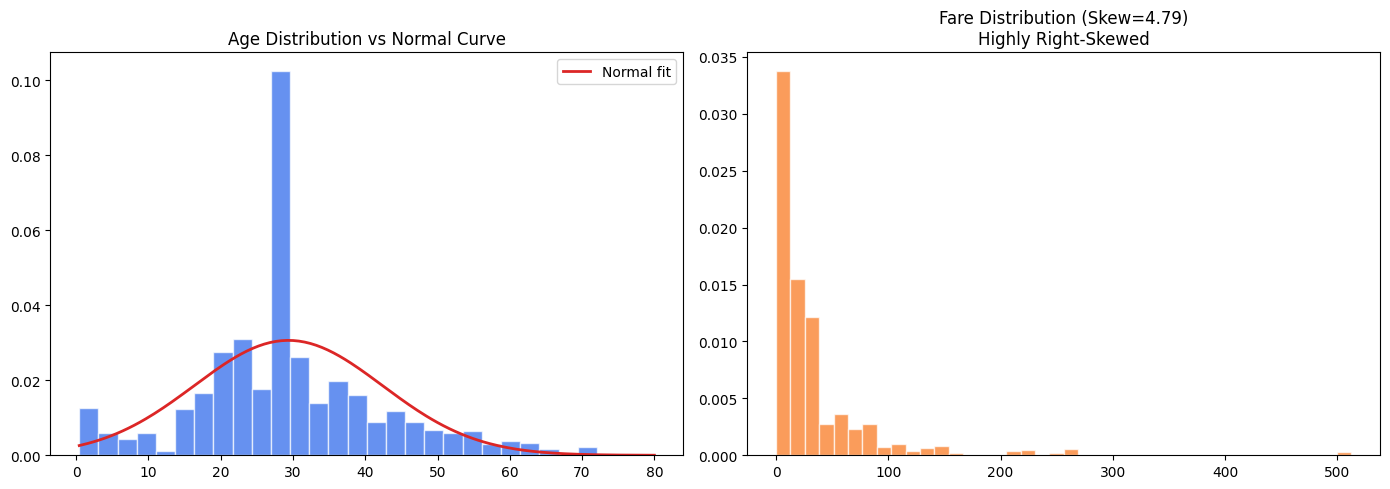

In [7]:
# Visual check: Histogram + Normal curve overlay 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age
ax = axes[0]
ax.hist(Titanic_cleaned['Age'], bins=30, density=True, color=BLUE, alpha=0.7, edgecolor='white')
mu, sigma = Titanic_cleaned['Age'].mean(), Titanic_cleaned['Age'].std()
x = np.linspace(Titanic_cleaned['Age'].min(), Titanic_cleaned['Age'].max(), 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color=RED, linewidth=2, label='Normal fit')
ax.set_title('Age Distribution vs Normal Curve'); ax.legend()

# Fare
ax = axes[1]
ax.hist(Titanic_cleaned['Fare'], bins=40, density=True, color=ORANGE, alpha=0.7, edgecolor='white')
ax.set_title(f'Fare Distribution (Skew={Titanic_cleaned["Fare"].skew():.2f})\nHighly Right-Skewed')

plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_3_Project\Week_3_Titanic_Project\Titanic_Histograms.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

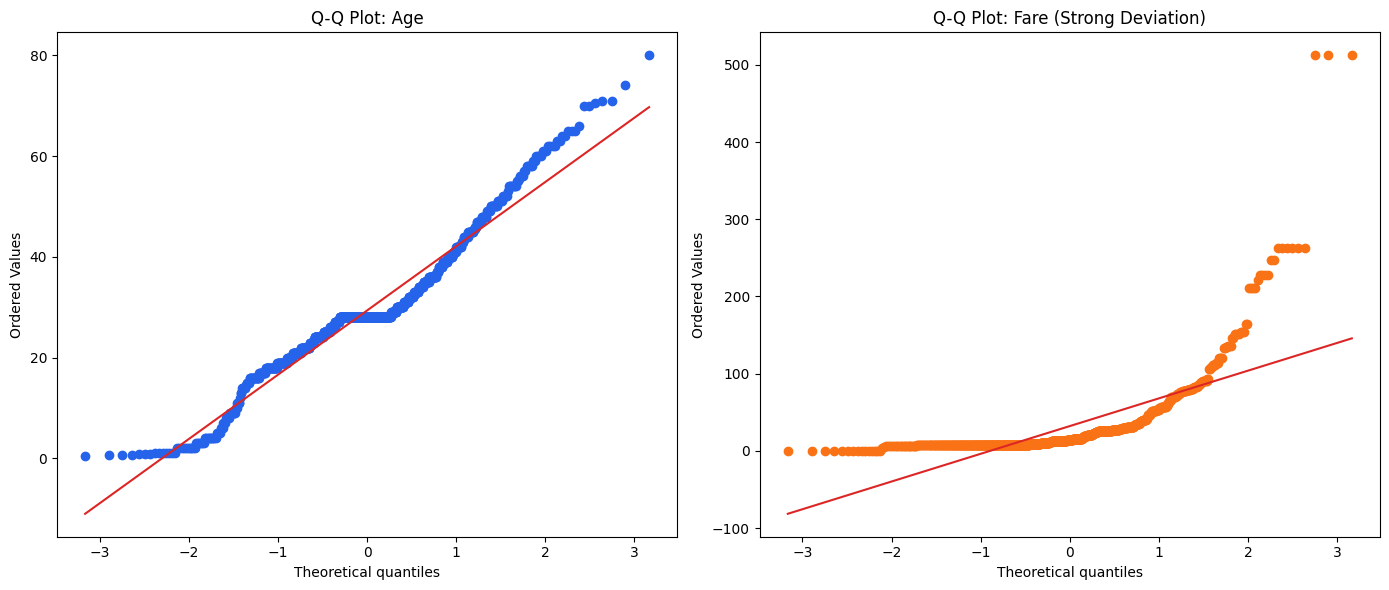

In [8]:
# Formal normality check
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

stats.probplot(Titanic_cleaned['Age'], dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot: Age')
axes[0].get_lines()[0].set_color(BLUE); axes[0].get_lines()[1].set_color(RED)

stats.probplot(Titanic_cleaned['Fare'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: Fare (Strong Deviation)')
axes[1].get_lines()[0].set_color(ORANGE); axes[1].get_lines()[1].set_color(RED)

plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_3_Project\Week_3_Titanic_Project\Titanic_Q_Q_Plots.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

In [9]:
# Shapiro-Wilk normality tests
stat_age, p_age = stats.shapiro(Titanic_cleaned['Age'])
stat_fare, p_fare = stats.shapiro(Titanic_cleaned['Fare'])

shapiro_results = pd.DataFrame({
    'Statistic': [stat_age, stat_fare],
    'P-Value': [p_age, p_fare]
}, index=['Age', 'Fare'])

shapiro_results['Normal?'] = shapiro_results['P-Value'].apply(
    lambda x: 'No (p < 0.05)' if x < 0.05 else 'Yes'
)

shapiro_results

,Statistic,P-Value,Normal?
Age,0.954105,4.651142e-16,No (p < 0.05)
Fare,0.521891,1.084044e-43,No (p < 0.05)


# Probability Distribution Key Observations

1. Age exhibits an approximately bell-shaped distribution but does not satisfy the assumption of normality according to the Shapiro–Wilk test (p < 0.05). The median imputation of 177 missing values may have contributed to this result by creating a concentration of observations around the median age.

2. Fare is strongly non-normal and highly positively skewed. Most passengers paid relatively low fares, while a small number paid exceptionally high fares, producing a long right tail extending to approximately £512.

3. The Shapiro–Wilk test indicates that both Age and Fare deviate significantly from a normal distribution. However, the departure from normality is substantially greater for Fare, consistent with its high skewness value.

4. Practical implication: Although Fare is not normally distributed, the Central Limit Theorem suggests that statistical procedures based on sample means (such as t-tests) can remain valid with sufficiently large samples. For predictive modelling or analyses that assume normality, a logarithmic transformation of Fare may be more appropriate.


# Hypothesis Testing

In [10]:
# Hypothesis Test 1: Does Fare differ between Survivors and Non-survivors? 

# H0: No difference in mean Fare between Survived and Died
# H1: There is a difference

surv_fare = Titanic_cleaned[Titanic_cleaned['Survived']==1]['Fare']
died_fare = Titanic_cleaned[Titanic_cleaned['Survived']==0]['Fare']
t_stat, p_val = stats.ttest_ind(surv_fare, died_fare, equal_var=False)

conclusion = ("Reject H0  Fare has a statistically significant relationship with survival"
              if p_val < 0.05 else "Fail to reject H0")

ttest_fare_results = pd.DataFrame({
    'Metric': ['Mean Fare (Survived)', 'Mean Fare (Died)', 'T-statistic', 'P-value', 'Conclusion'],
    'Value': [f'£{surv_fare.mean():.2f}', f'£{died_fare.mean():.2f}',
              f'{t_stat:.3f}', f'{p_val:.6f}', conclusion]
})

ttest_fare_results

,Metric,Value
0,Mean Fare (Survived),£48.40
1,Mean Fare (Died),£22.12
2,T-statistic,6.839
3,P-value,0.000000
4,Conclusion,Reject H0 Fare has a statistically significan...


In [11]:
# Hypothesis Test 2: Is Sex independent of Survival? (Chi-Square Test)

# H0: Sex and Survival are independent
# H1: Sex and Survival are NOT independent (i.e. there is an association)

contingency = pd.crosstab(Titanic_cleaned['Sex'], Titanic_cleaned['Survived'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)

conclusion = ("Reject H0  Sex and Survival are significantly associated"
              if p_chi < 0.05 else "Fail to reject H0")

chi2_sex_results = pd.DataFrame({
    'Metric': ['Chi-square statistic', 'Degrees of freedom', 'P-value', 'Conclusion'],
    'Value': [f'{chi2:.3f}', f'{dof}', f'{p_chi:.10f}', conclusion]
})

display(contingency)
display(chi2_sex_results)

Survived,0,1
Sex,,
female,81,233
male,468,109


,Metric,Value
0,Chi-square statistic,260.717
1,Degrees of freedom,1
2,P-value,0.0000000000
3,Conclusion,Reject H0 Sex and Survival are significantly ...


In [12]:
# Hypothesis Test 3: Is Pclass independent of Survival? (Chi-Square Test)

# H0: Pclass and Survival are independent
# H1: Pclass and Survival are NOT independent (i.e. there is an association)

contingency2 = pd.crosstab(Titanic_cleaned['Pclass'], Titanic_cleaned['Survived'])
chi2b, p_chib, dofb, _ = stats.chi2_contingency(contingency2)

conclusion = ("Reject H0  Passenger Class and Survival are significantly associated"
              if p_chib < 0.05 else "Fail to reject H0")

chi2_pclass_results = pd.DataFrame({
    'Metric': ['Chi-square statistic', 'Degrees of freedom', 'P-value', 'Conclusion'],
    'Value': [f'{chi2b:.3f}', f'{dofb}', f'{p_chib:.10f}', conclusion]
})

display(contingency2)
display(chi2_pclass_results)

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


,Metric,Value
0,Chi-square statistic,102.889
1,Degrees of freedom,2
2,P-value,0.0000000000
3,Conclusion,Reject H0 Passenger Class and Survival are si...


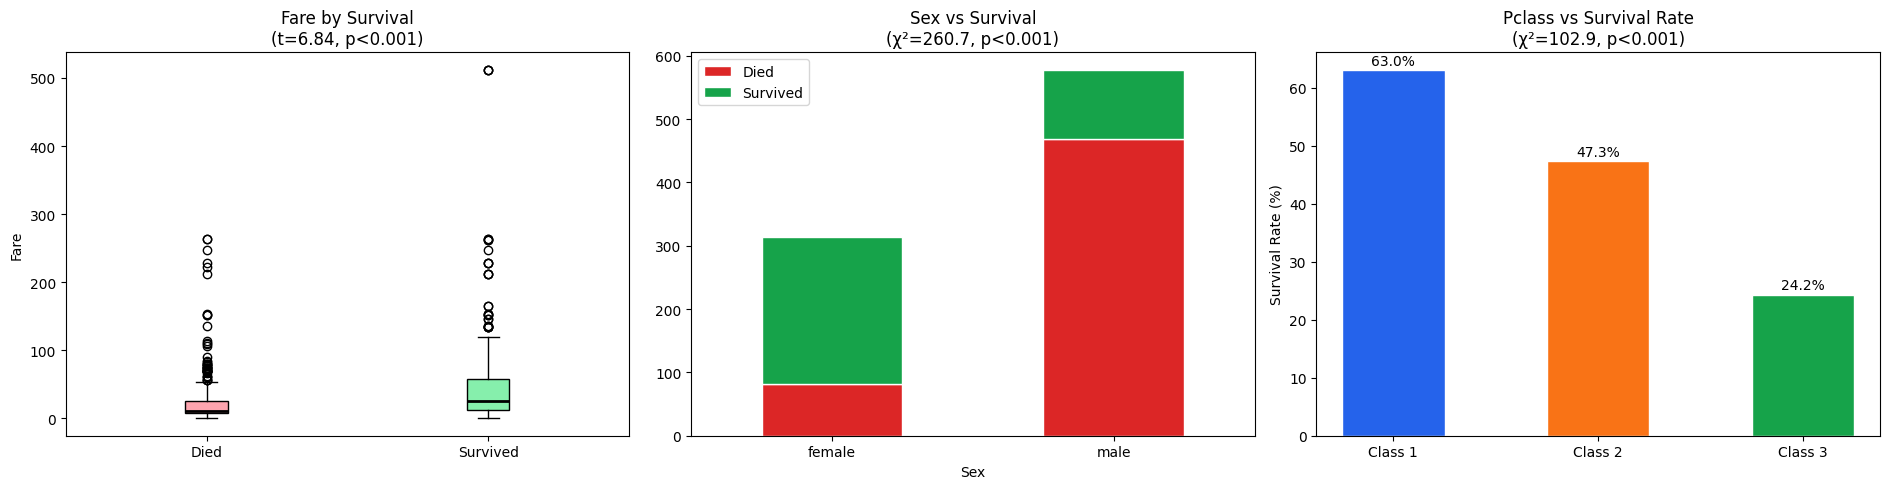

In [13]:
# Visualizing the hypothesis tests 

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# Fare boxplot
data = [died_fare, surv_fare]
bp = axes[0].boxplot(data, patch_artist=True, labels=['Died','Survived'], medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#FDA4AF'); bp['boxes'][1].set_facecolor('#86EFAC')
axes[0].set_title(f'Fare by Survival\n(t={t_stat:.2f}, p<0.001)')
axes[0].set_ylabel('Fare')

# Sex stacked bar
contingency.plot(kind='bar', stacked=True, ax=axes[1], color=[RED, GREEN], edgecolor='white')
axes[1].set_title(f'Sex vs Survival\n(\u03c7\u00b2={chi2:.1f}, p<0.001)')
axes[1].legend(['Died','Survived']); axes[1].tick_params(axis='x', rotation=0)

# Pclass survival rate bar
pclass_surv = Titanic_cleaned.groupby('Pclass')['Survived'].mean()*100
bars = axes[2].bar([f'Class {i}' for i in pclass_surv.index], pclass_surv.values, color=[BLUE,ORANGE,GREEN], edgecolor='white', width=0.5)
axes[2].set_title(f'Pclass vs Survival Rate\n(\u03c7\u00b2={chi2b:.1f}, p<0.001)')
axes[2].set_ylabel('Survival Rate (%)')
for bar in bars:
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{bar.get_height():.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(r"C:\Users\ThePhantomTrader\OneDrive\Desktop\AnalystLabs\Week_3_Project\Week_3_Titanic_Project\Titanic_Hypothesis_Tests.png",
            dpi=300,
            bbox_inches='tight')
plt.show()

# Hypothesis Testing Key Observations

1. Fare vs Survival (Independent Samples t-test): The difference in mean fares between survivors and non-survivors was statistically significant (t = 6.84, p < 0.001). On average, survivors paid substantially higher fares (£48.40) than non-survivors (£22.12).

2. Sex vs Survival (Chi-square Test of Independence): A significant association was found between passenger sex and survival status (χ² = 260.72, p < 0.001). Survival rates differed markedly between males and females, indicating that sex was strongly related to survival outcomes.

3. Passenger Class vs Survival (Chi-square Test of Independence): A significant association was also observed between passenger class and survival status (χ² = 102.89, p < 0.001). Survival rates varied considerably across classes, suggesting that passenger class influenced the likelihood of survival.


Overall Conclusion: All three hypothesis tests produced p-values below 0.001, leading to the rejection of their respective null hypotheses. The results provide strong statistical evidence that fare, sex, and passenger class were associated with survival on the Titanic.


# Correlation vs Causation
This dataset is a textbook case for distinguishing correlation from causation, because the underlying historical mechanism (evacuation protocol) is well documented.

In [14]:
# Point-biserial / correlation analysis: Sex_enc vs Survived

r1, p1 = stats.pointbiserialr(Titanic_cleaned['Sex_enc'], Titanic_cleaned['Survived'])
r2, p2 = stats.pointbiserialr(Titanic_cleaned['Survived'], Titanic_cleaned['Fare'])
r3 = Titanic_cleaned['Pclass'].corr(Titanic_cleaned['Survived'])

correlation_results = pd.DataFrame({
    'Comparison': ['Sex vs Survived', 'Survived vs Fare', 'Pclass vs Survived'],
    'Correlation (r)': [f'{r1:.3f}', f'{r2:.3f}', f'{r3:.3f}'],
    'P-value': [f'{p1:.6f}', f'{p2:.6f}', '—']
})

display(correlation_results)

,Comparison,Correlation (r),P-value
0,Sex vs Survived,0.543,0.000000
1,Survived vs Fare,0.257,0.000000
2,Pclass vs Survived,-0.338,—


# Correlation vs Causation Critical Discussion

1. Sex is strongly associated with Survival (r = 0.54).

Unlike many correlations observed in datasets, this relationship is supported by historical evidence. Accounts of the Titanic disaster indicate that the evacuation process prioritized women and children, providing a plausible mechanism linking passenger sex to survival outcomes. While observational data alone cannot prove causation, the historical context strengthens the case for a causal interpretation.

2. Fare is positively associated with Survival (r = 0.26),but this does not imply that fare itself caused survival. Fare is more appropriately viewed as a proxy for socioeconomic status, passenger class, and cabin location. A more plausible causal pathway is: Wealth → Passenger Class/Cabin Location → Access to Lifeboats and Assistance → Survival. Thus, fare reflects underlying advantages rather than directly influencing survival.

3. Embarked Port shows a weak association with Survival (r ≈ 0.11), yet there is no convincing mechanism by which boarding at a particular port would directly affect survival. This relationship is likely confounded by other factors, particularly passenger class distribution. For example, passengers embarking at Cherbourg included a higher proportion of first-class travelers, who generally experienced higher survival rates.


When evaluating whether a relationship is causal, three key questions are useful:

  1. Is there a plausible mechanism linking the variables?
  2. Could a third variable explain the observed association?
  3. Is the temporal sequence consistent with a causal effect?

Applying these principles suggests that the association between Sex and Survival has the strongest support for a causal interpretation, whereas the relationships involving Fare and Embarked Port are more likely explained by confounding factors, particularly passenger class and socioeconomic status.


Conclusion: The analysis demonstrates that correlation alone does not imply causation. Although Fare and Embarked Port are associated with survival, these relationships are largely indirect. In contrast, the historical evacuation policy provides a credible mechanism supporting the observed relationship between Sex and Survival.



## Summary of Findings

| Concept | Finding |
|---------|---------|
| Descriptive Stats | Fare is extremely right-skewed (skew=4.79); Age is mildly skewed |
| Probability Distribution | Neither Age nor Fare is normally distributed (Shapiro-Wilk p<0.05) |
| Hypothesis Test 1 | Fare differs significantly by survival outcome (p<0.001) |
| Hypothesis Test 2 | Sex and Survival are significantly associated (χ²=260.7, p<0.001) |
| Hypothesis Test 3 | Pclass and Survival are significantly associated (χ²=102.9, p<0.001) |
| Correlation vs Causation | Sex→Survival has genuine causal support (historical protocol); Fare and Embarked are confounded by Class |